<a href="https://colab.research.google.com/github/saeedbhai0632-web/Math-to-Magic/blob/main/learnings/first_generative_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons

# Generate 2D moons: two interleaving crescent shapes
def get_moons(batch_size=256):
    X, _ = make_moons(n_samples=3000, noise=0.05)
    X = torch.FloatTensor(X)
    dataset = TensorDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()
        # Encoder: input -> 2 * latent_dim (mean + logvar for each)
        self.encoder = nn.Sequential(nn.Linear(input_dim,128),
        nn.ReLU(),
        nn.Linear(128,128),
        nn.ReLU(),
        nn.Linear(128,latent_dim*2))
        # Decoder: latent code -> reconstructed input
        self.decoder = nn.Sequential(
    nn.Linear(latent_dim, 128),
    nn.ReLU(),
    nn.Linear(128,128),
    nn.ReLU(),


    nn.Linear(128, input_dim)
)

    def encode(self, x):
        h = self.encoder(x)
        # Split output into mean and log-variance
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * epsilon  where epsilon ~ N(0, I)
        std = torch.exp(0.5 * logvar)        # sigma = exp(0.5 * log(sigma^2))
        eps = torch.randn_like(std)          # random noise
        return mu + eps * std                # differentiable!

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar,beta=0.01):
    # Term 1: Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')

    # Term 2: KL divergence from N(0, I)
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta*kl_loss, recon_loss, kl_loss

In [ ]:
def train_vae(model, train_loader, epochs=200, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Loss: {total_loss:.2f} | Recon: {total_recon:.2f} | KL: {total_kl:.2f}")

In [ ]:
import matplotlib.pyplot as plt

def plot_reconstructions(model, data, n=10):
    with torch.no_grad():
        recon, _, _ = model(data[:n])

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(data[:n, 0], data[:n, 1], c='blue', alpha=0.6)
    plt.title('Original Data')
    plt.subplot(1, 2, 2)
    plt.scatter(recon[:, 0], recon[:, 1], c='red', alpha=0.6)
    plt.title('Reconstructed Data')
    plt.show()

In [ ]:
def plot_latent_space(model, data):
    with torch.no_grad():
        mu, logvar = model.encode(data)

    plt.figure(figsize=(6, 6))
    plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5, s=10)
    plt.xlabel('Latent dim 1')
    plt.ylabel('Latent dim 2')
    plt.title('Latent Space')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def plot_generated(model, n=1000):
    with torch.no_grad():
        z = torch.randn(n, 2)   # Sample from N(0, I)
        samples = model.decode(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5)
    plt.title('Generated Samples -- Pure Creation from Noise')
    plt.grid(True, alpha=0.3)
    plt.show()

#MY CODE

Epoch   0 | Loss: 2961.19 | Recon: 2956.82 | KL: 437.12
Epoch  20 | Loss: 159.57 | Recon: 33.51 | KL: 12606.22
Epoch  40 | Loss: 153.03 | Recon: 32.46 | KL: 12056.70
Epoch  60 | Loss: 149.49 | Recon: 31.23 | KL: 11825.84
Epoch  80 | Loss: 148.66 | Recon: 31.47 | KL: 11718.74
Epoch 100 | Loss: 145.88 | Recon: 31.47 | KL: 11441.17
Epoch 120 | Loss: 144.45 | Recon: 31.95 | KL: 11249.76
Epoch 140 | Loss: 143.12 | Recon: 30.50 | KL: 11262.31
Epoch 160 | Loss: 140.74 | Recon: 29.44 | KL: 11129.68
Epoch 180 | Loss: 140.61 | Recon: 28.74 | KL: 11186.80
Epoch 200 | Loss: 141.05 | Recon: 29.88 | KL: 11117.03
Epoch 220 | Loss: 138.32 | Recon: 28.58 | KL: 10973.65
Epoch 240 | Loss: 139.59 | Recon: 31.24 | KL: 10835.64
Epoch 260 | Loss: 140.01 | Recon: 30.76 | KL: 10925.37
Epoch 280 | Loss: 136.29 | Recon: 29.17 | KL: 10712.14
Epoch 300 | Loss: 137.03 | Recon: 29.89 | KL: 10714.07
Epoch 320 | Loss: 138.48 | Recon: 27.72 | KL: 11076.04
Epoch 340 | Loss: 135.94 | Recon: 26.88 | KL: 10906.09
Epoch 360

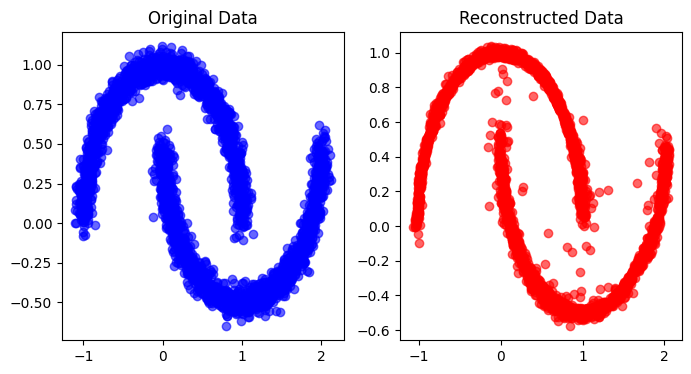

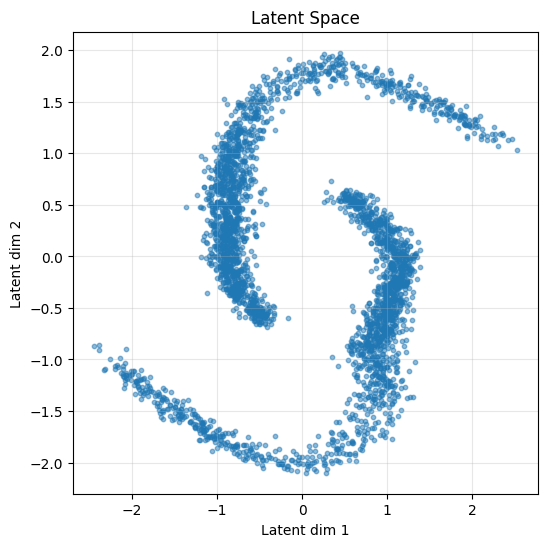

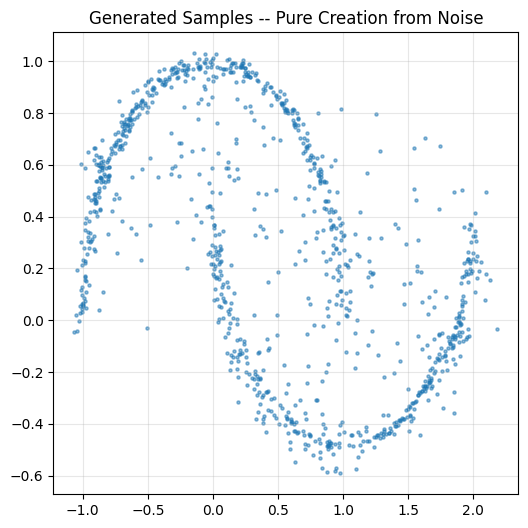

In [ ]:
train_loader = get_moons(batch_size=256)
model = LinearVAE(input_dim=2, latent_dim=2)
train_vae(model, train_loader, epochs=500)
X, _ = make_moons(n_samples=3000, noise=0.05)
data = torch.FloatTensor(X)
plot_reconstructions(model, data, n=10000)
plot_latent_space(model, data)
plot_generated(model,1000)